In [25]:
import pandas as pd

# -------------------------------
# 1. Load Dataset
# -------------------------------
df = pd.read_csv("Food_Delivery_Times.csv")

# -------------------------------
# 2. Standardize Column Names
# -------------------------------
df.columns = df.columns.str.strip().str.lower()

print("Columns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

# -------------------------------
# 3. Handle Missing Values
# -------------------------------

# Fix empty strings in categorical column
df['time_of_day'] = df['time_of_day'].replace('', pd.NA)

# Fill categorical with mode
df['time_of_day'] = df['time_of_day'].fillna(df['time_of_day'].mode()[0])

# -------------------------------
# 4. Clean Categorical Columns
# -------------------------------
cat_cols = ['weather', 'traffic_level', 'time_of_day', 'vehicle_type']

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()

# -------------------------------
# 5. Handle Numeric Missing Values
# -------------------------------
num_cols = ['distance_km', 'preparation_time_min', 'courier_experience_yrs', 'delivery_time_min']

for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

# -------------------------------
# 6. Outlier Detection (IQR)
# -------------------------------
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in num_cols:
    if col in df.columns:
        df = remove_outliers(df, col)

# -------------------------------
# 7. Final Output
# -------------------------------
print("\nFinal Shape:", df.shape)
print("\nCleaned Data:\n", df.head())

Columns:
 Index(['order_id', 'distance_km', 'weather', 'traffic_level', 'time_of_day',
       'vehicle_type', 'preparation_time_min', 'courier_experience_yrs',
       'delivery_time_min'],
      dtype='object')

Missing Values:
 order_id                   0
distance_km                0
weather                   30
traffic_level             30
time_of_day               30
vehicle_type               0
preparation_time_min       0
courier_experience_yrs    30
delivery_time_min          0
dtype: int64

Final Shape: (994, 9)

Cleaned Data:
    order_id  distance_km weather traffic_level time_of_day vehicle_type  \
0       522         7.93   windy           low   afternoon      scooter   
1       738        16.42   clear        medium     evening         bike   
2       741         9.52   foggy           low       night      scooter   
3       661         7.44   rainy        medium   afternoon      scooter   
4       412        19.03   clear           low     morning         bike   

   prep

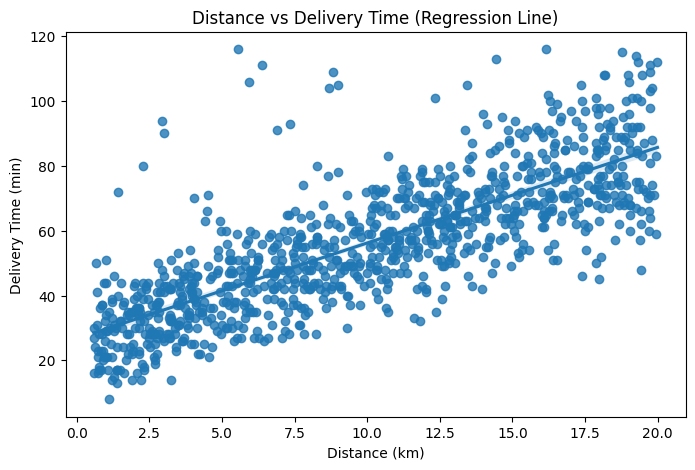

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.regplot(x='distance_km', y='delivery_time_min', data=df)

plt.title("Distance vs Delivery Time (Regression Line)")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.show()

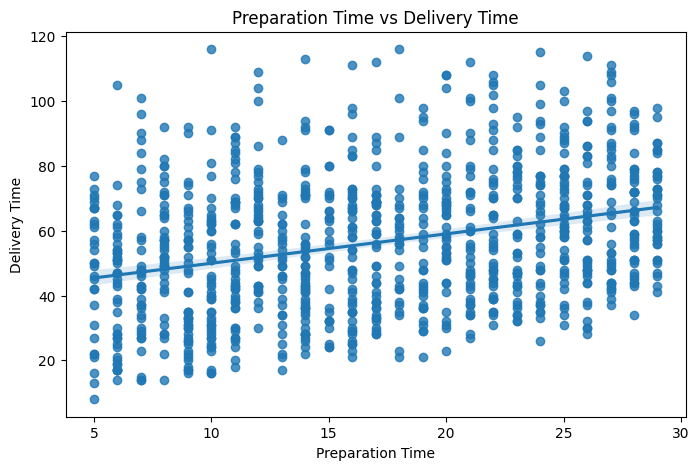

In [27]:
plt.figure(figsize=(8,5))
sns.regplot(x='preparation_time_min', y='delivery_time_min', data=df)

plt.title("Preparation Time vs Delivery Time")
plt.xlabel("Preparation Time")
plt.ylabel("Delivery Time")
plt.show()

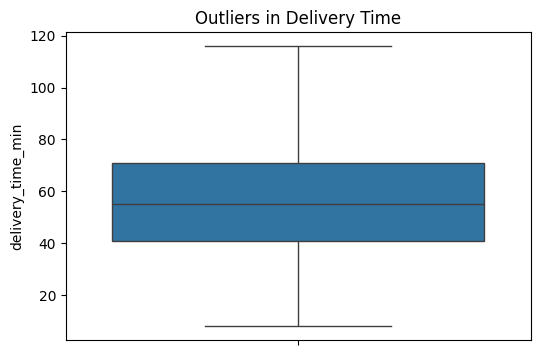

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['delivery_time_min'])

plt.title("Outliers in Delivery Time")
plt.show()

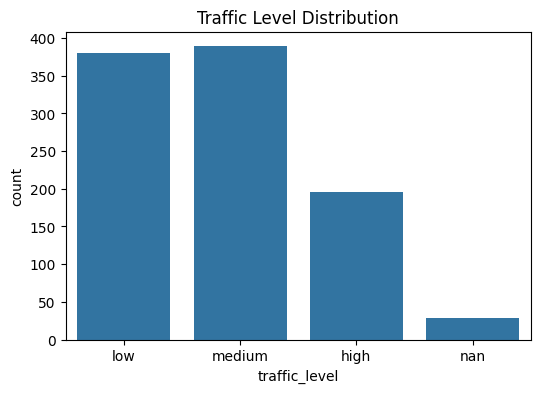

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x='traffic_level', data=df)

plt.title("Traffic Level Distribution")
plt.show()

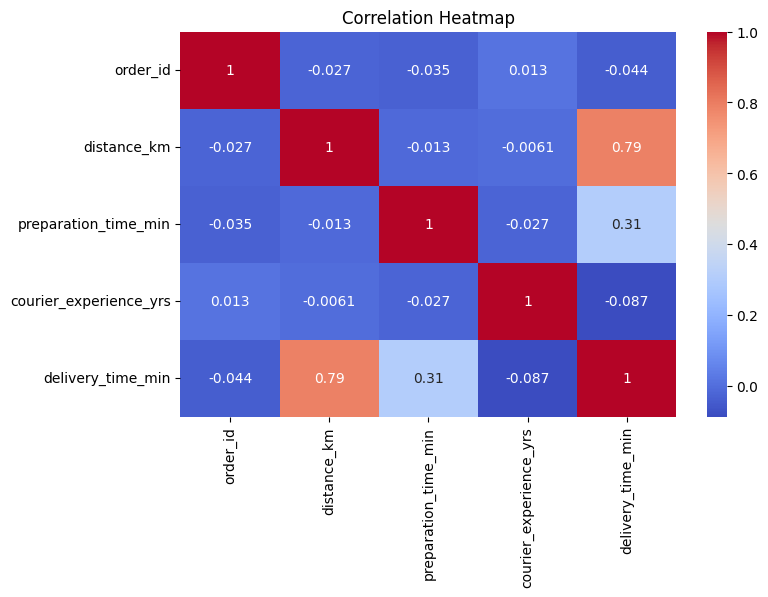

In [30]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()